In [6]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')
import numpy as np
from datetime import datetime

# # # # # # # # # # # # # # #
save = True
fp_type = 'morgan'
cnts = False
bits = 1024
r = 2
dist_type = 'euclidean'
# # # # # # # # # # # # # # #

today = datetime.today().strftime('%Y%m%d%H')

if cnts==False:
    c = 'bitv'
elif cnts==True:
    c = 'cntv'
    
if dist_type=='euclidean':
    d = 'eucnorm'

rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

v = '_'.join(['baseline','2000n_test',fp_type,c,f'{bits}b',f'{r}r',d])
tag = f'{today}_{v}'
print(tag)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2022050300_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm


## 1) Calculate fps.

In [13]:
import pandas as pd
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from sklearn import preprocessing

umap_tag = '2022041804_04_12000n_extended_32neigh_mindist0pt1'

df = pd.read_csv(f'{rdir}umap_dfs/{umap_tag}.csv', usecols=["Smiles","Label","Atype"])
display(df)

fps = get_fps_in_parallel(df.Smiles,fp_type,counts=cnts,bits=bits,)
fps = np.stack(fps)

if dist_type=='euclidean':
    fps = preprocessing.normalize(fps, norm='l2', axis=1)
print(fps.shape)

,Smiles,Atype,Label
0,CC(C)N(C)CC(O)COc1ccccc1,Anc,0
1,O=C(CSc1nc[nH]n1)c1cc2ccccc2o1,Anc,1
2,Cc1cc(Br)ccc1OCCCCNC(C)(C)C,Anc,2
3,O=C(CCNC(=O)c1ccc(Cl)cc1)Nc1ccc(Cl)cc1F,Anc,3
4,CCCn1nc(-c2cn(Cc3ccc(Cl)c(Cl)c3)c3ccccc23)cc1C...,Anc,4
...,...,...,...
11995,CCOC(=O)N1CCN(C(=O)COC(=O)c2cccc(S(C)(=O)=O)c2...,Anc,11995
11996,COc1cc(C(C)=O)ccc1OCc1cc(C(=O)N2CCSCC2)no1,Anc,11996
11997,CC(C)Oc1c(C(C)C)c(O)c2c(=O)cc(-c3ccccc3)oc2c1C...,Anc,11997
11998,c1ccc(CC2NCCc3c2[nH]c2ccccc32)cc1,Anc,11998


(12000, 1024)


## 2) UMAP down to 32d for comparison ...

In [14]:
import umap.umap_ as umap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

umapper = umap.UMAP(n_neighbors=32, min_dist=0.1, 
                    n_components=32, metric='euclidean')
embedding = umapper.fit_transform(fps)

## 3) Calculate properties.

In [15]:
from rdkit.Chem import rdMolDescriptors, Descriptors, Crippen
import pandas as pd
from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
# df = df[["Smiles","Mol","Label","Atype","x","y"]]

my_props = [(Descriptors.MolWt, "MolWt"),
            (Descriptors.HeavyAtomCount, "HeavyAtomCount"), 
            (Descriptors.FractionCSP3, "FractionCSP3"), 
            (Descriptors.TPSA, "TPSA"), 
            (Descriptors.NumHAcceptors, "NumHAcceptors"), 
            (Descriptors.NumHDonors, "NumHDonors"), 
            (Descriptors.NumRotatableBonds, "NumRotatableBonds"), 
            (Crippen.MolLogP, "MolLogP"),
           ]

my_props_names = [x[1] for x in my_props]

for descriptor, name in my_props:
    props = [descriptor(m) for m in df.Mol] 
    df[name] = props

In [16]:
df = df.drop('Mol',axis=1,errors='ignore')
df

,Smiles,Atype,Label,MolWt,HeavyAtomCount,FractionCSP3,TPSA,NumHAcceptors,NumHDonors,NumRotatableBonds,MolLogP
0,CC(C)N(C)CC(O)COc1ccccc1,Anc,0,223.316,16,0.538462,32.70,3,1,6,1.76650
1,O=C(CSc1nc[nH]n1)c1cc2ccccc2o1,Anc,1,259.290,18,0.083333,71.78,5,1,4,2.52590
2,Cc1cc(Br)ccc1OCCCCNC(C)(C)C,Anc,2,314.267,18,0.600000,21.26,2,1,6,4.30462
3,O=C(CCNC(=O)c1ccc(Cl)cc1)Nc1ccc(Cl)cc1F,Anc,3,355.196,23,0.125000,58.20,2,2,5,3.89110
4,CCCn1nc(-c2cn(Cc3ccc(Cl)c(Cl)c3)c3ccccc23)cc1C...,Anc,4,442.350,30,0.181818,77.87,5,2,6,4.87340
...,...,...,...,...,...,...,...,...,...,...,...
11995,CCOC(=O)N1CCN(C(=O)COC(=O)c2cccc(S(C)(=O)=O)c2...,Anc,11995,398.437,27,0.470588,110.29,7,0,5,0.54760
11996,COc1cc(C(C)=O)ccc1OCc1cc(C(=O)N2CCSCC2)no1,Anc,11996,376.434,26,0.388889,81.87,7,0,6,2.65380
11997,CC(C)Oc1c(C(C)C)c(O)c2c(=O)cc(-c3ccccc3)oc2c1C...,Anc,11997,380.484,28,0.375000,59.67,4,1,5,6.19960
11998,c1ccc(CC2NCCc3c2[nH]c2ccccc32)cc1,Anc,11998,262.356,20,0.222222,27.82,1,2,2,3.59740


## 4) Get mutual info for each (latent dimension)-(property) pair.

In [17]:
def corr(x,y):
    rowvar = 1 if x.shape[0] == 0 else 0
    return np.corrcoef(np.asarray(x),np.asarray(y),rowvar = rowvar)[0,1]

def mutual_info(x,y):
    return -1.0/2.0*np.log(1.0 - corr(x,y)**2.0)    

In [24]:
space = fps # embedding

mi_array = np.zeros((space.shape[1], len(my_props_names)))
print(mi_array.shape)

(1024, 8)


In [25]:
for i,dim in enumerate(space.T):
#     print(latent.shape)
    for j,prop in enumerate(my_props_names):
        prop_vals = np.squeeze(df[[prop]].values)       
        mi = mutual_info(dim,prop_vals)
        mi_array[i][j] = mi

In [28]:
df_mi = pd.DataFrame(mi_array, columns=my_props_names)
df_mi.to_csv("2022041804_04_12000n_extended_morgan.csv",index=False)

In [27]:
for prop in df_mi:
    print(prop)
    print(df_mi[prop].mean())
    print(df[prop].median())
    print("------")

MolWt
0.0005199985601929741
342.3910000000001
------
HeavyAtomCount
0.00044577789980041426
24.0
------
FractionCSP3
0.0027079621931871993
0.29411764705882354
------
TPSA
0.0010709297754199713
66.39999999999999
------
NumHAcceptors
0.0011257615259705432
4.0
------
NumHDonors
0.0011199520634874094
1.0
------
NumRotatableBonds
0.0015311897345291665
4.0
------
MolLogP
0.0009311792604296305
3.068250000000001
------


In [44]:
df_mi_melt = pd.melt(df_mi, var_name='Property',value_name='Mutual info')
df_mi_melt

,Property,Mutual info
0,MolWt,0.253637
1,MolWt,0.080362
2,MolWt,0.056961
3,MolWt,0.143544
4,MolWt,0.028324
...,...,...
251,MolLogP,0.049089
252,MolLogP,0.006864
253,MolLogP,0.024371
254,MolLogP,0.067293


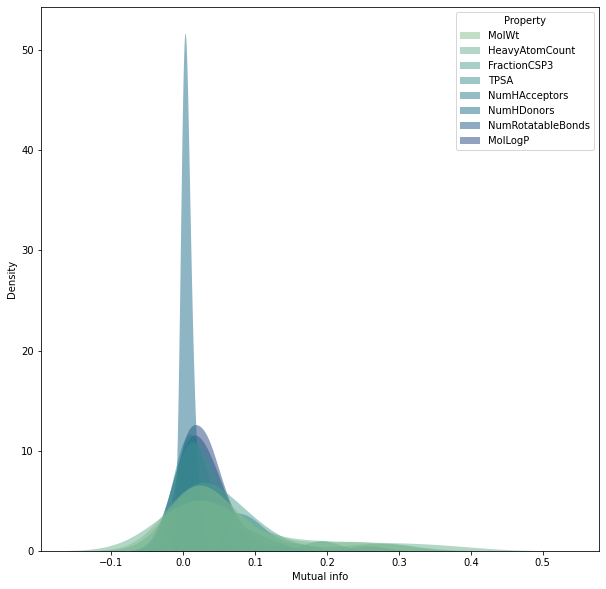

In [48]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.kdeplot(
   data=df_mi_melt, x="Mutual info", hue="Property",
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,)
display()